# CAERS Adverse Event Reports - Data Exploration

This notebook explores the **FDA CFSAN Adverse Event Reporting System (CAERS)** dataset (2004–2017 Q2), which contains reports of adverse events and product complaints related to foods, dietary supplements, and cosmetics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load and Preview the Data

In [2]:
df = pd.read_csv("CAERS_ASCII_2004_2017Q2.csv")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 90,786 rows × 12 columns


,RA_Report #,RA_CAERS Created Date,AEC_Event Start Date,PRI_Product Role,PRI_Reported Brand/Product Name,PRI_FDA Industry Code,PRI_FDA Industry Name,CI_Age at Adverse Event,CI_Age Unit,CI_Gender,AEC_One Row Outcomes,SYM_One Row Coded Symptoms
0,65325,1/1/2004,8/4/2003,Suspect,MIDWEST COUNTRY FAIR CHOCOLATE FLAVORED CHIPS,3,Bakery Prod/Dough/Mix/Icing,2.0,Year(s),Female,"VISITED AN ER, VISITED A HEALTH CARE PROVIDER,...","SWELLING FACE, RASH, WHEEZING, COUGH, HOSPITAL..."
1,65325,1/1/2004,8/4/2003,Suspect,MIDWEST COUNTRY FAIR CHOCOLATE FLAVORED CHIPS,3,Bakery Prod/Dough/Mix/Icing,2.0,Year(s),Female,"VISITED AN ER, VISITED A HEALTH CARE PROVIDER,...","SWELLING FACE, WHEEZING, COUGH, RASH, HOSPITAL..."
2,65333,1/1/2004,NaN,Suspect,KROGER CLASSIC CREAM-DE-MINT CANDY MINT CHIP I...,13,Ice Cream Prod,NaN,Not Available,Female,VISITED AN ER,"NAUSEA, DYSGEUSIA, DIARRHOEA"
3,65335,1/1/2004,11/24/2003,Suspect,ENFAMIL LIPIL BABY FORMULA,40,Baby Food Prod,3.0,Month(s),Not Available,NON-SERIOUS INJURIES/ ILLNESS,"GASTROINTESTINAL DISORDER, VOMITING"
4,65336,1/1/2004,NaN,Suspect,ENFIMIL LIPIL BABY FORMULA,40,Baby Food Prod,NaN,Not Available,Not Available,VISITED A HEALTH CARE PROVIDER,"GASTROINTESTINAL DISORDER, PHYSICAL EXAMINATION"


## 2. Data Types and Missing Values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90786 entries, 0 to 90785
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   RA_Report #                      90786 non-null  int64  
 1   RA_CAERS Created Date            90786 non-null  object 
 2   AEC_Event Start Date             53653 non-null  object 
 3   PRI_Product Role                 90786 non-null  object 
 4   PRI_Reported Brand/Product Name  90786 non-null  object 
 5   PRI_FDA Industry Code            90786 non-null  int64  
 6   PRI_FDA Industry Name            90786 non-null  object 
 7   CI_Age at Adverse Event          52926 non-null  float64
 8   CI_Age Unit                      90786 non-null  object 
 9   CI_Gender                        90786 non-null  object 
 10  AEC_One Row Outcomes             90786 non-null  object 
 11  SYM_One Row Coded Symptoms       90781 non-null  object 
dtypes: float64(1), int

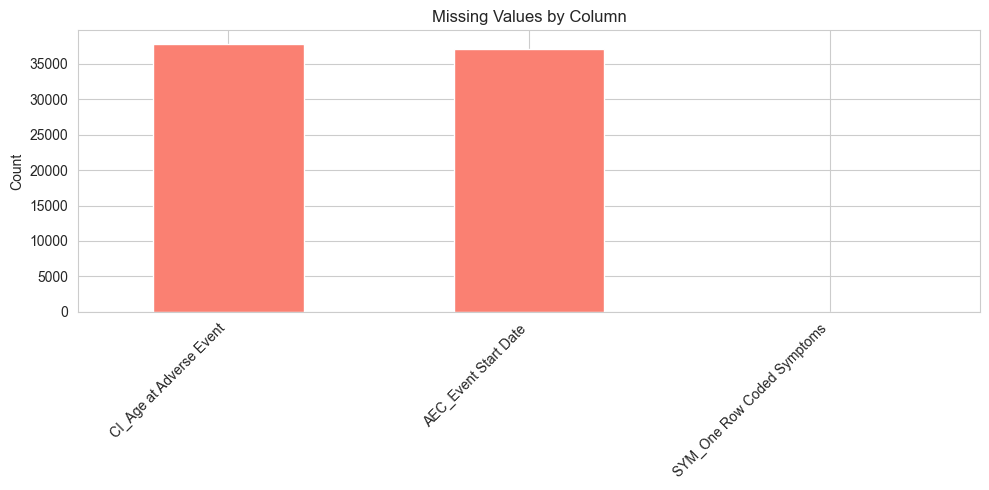

In [4]:
# Visualize missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 5))
missing.plot(kind="bar", ax=ax, color="salmon")
ax.set_title("Missing Values by Column")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Reports Over Time

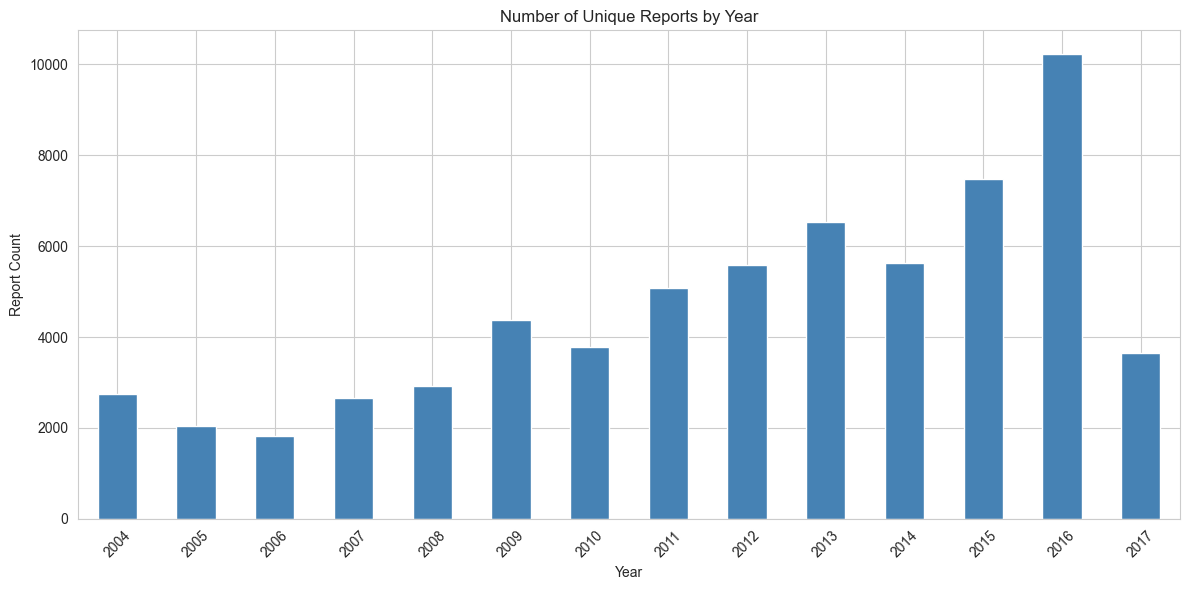

In [5]:
df["RA_CAERS Created Date"] = pd.to_datetime(df["RA_CAERS Created Date"], format="%m/%d/%Y")
df["Year"] = df["RA_CAERS Created Date"].dt.year

reports_by_year = df.groupby("Year")["RA_Report #"].nunique()

fig, ax = plt.subplots()
reports_by_year.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of Unique Reports by Year")
ax.set_ylabel("Report Count")
ax.set_xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Top FDA Industry Categories

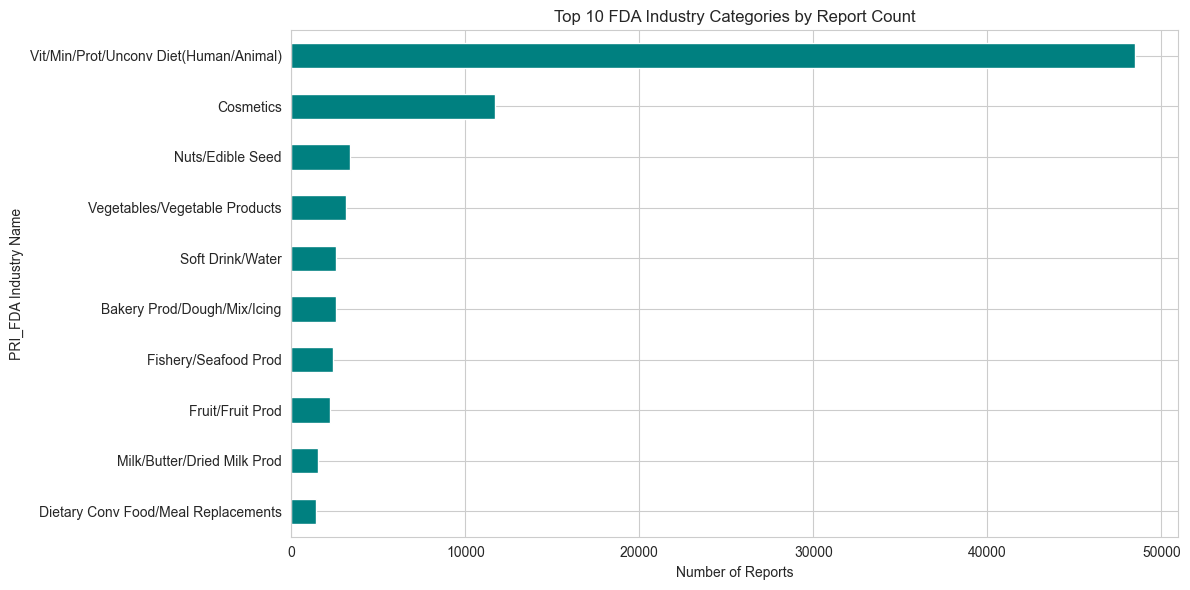

In [6]:
top_industries = df["PRI_FDA Industry Name"].value_counts().head(10)

fig, ax = plt.subplots()
top_industries.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 10 FDA Industry Categories by Report Count")
ax.set_xlabel("Number of Reports")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Gender Distribution

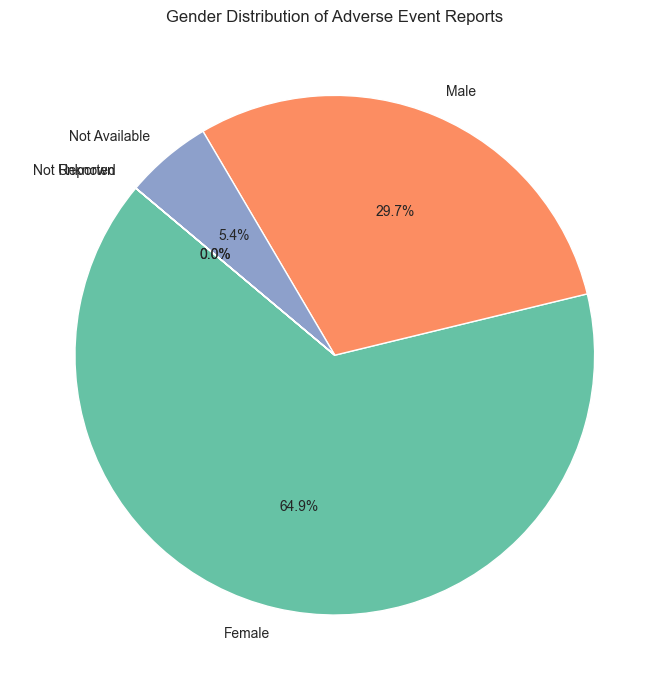

In [7]:
gender_counts = df["CI_Gender"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=140,
       colors=sns.color_palette("Set2"))
ax.set_title("Gender Distribution of Adverse Event Reports")
plt.tight_layout()
plt.show()

## 6. Most Common Symptoms

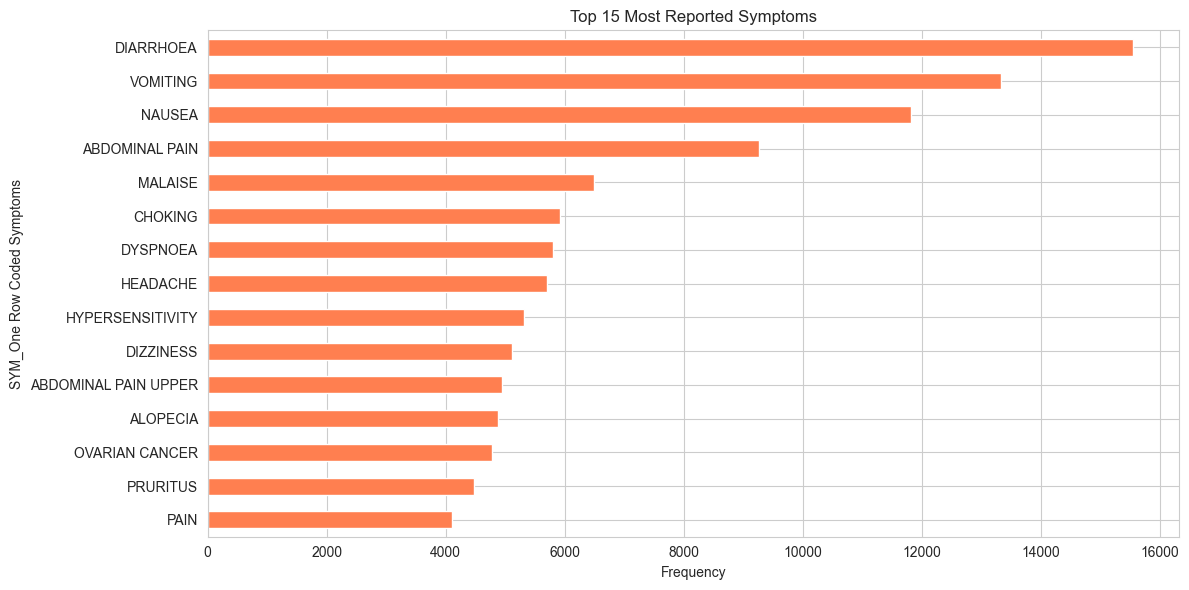

In [8]:
# Split comma-separated symptoms and count individual occurrences
all_symptoms = df["SYM_One Row Coded Symptoms"].dropna().str.split(", ").explode().str.strip()
top_symptoms = all_symptoms.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_symptoms.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Top 15 Most Reported Symptoms")
ax.set_xlabel("Frequency")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Outcome Distribution

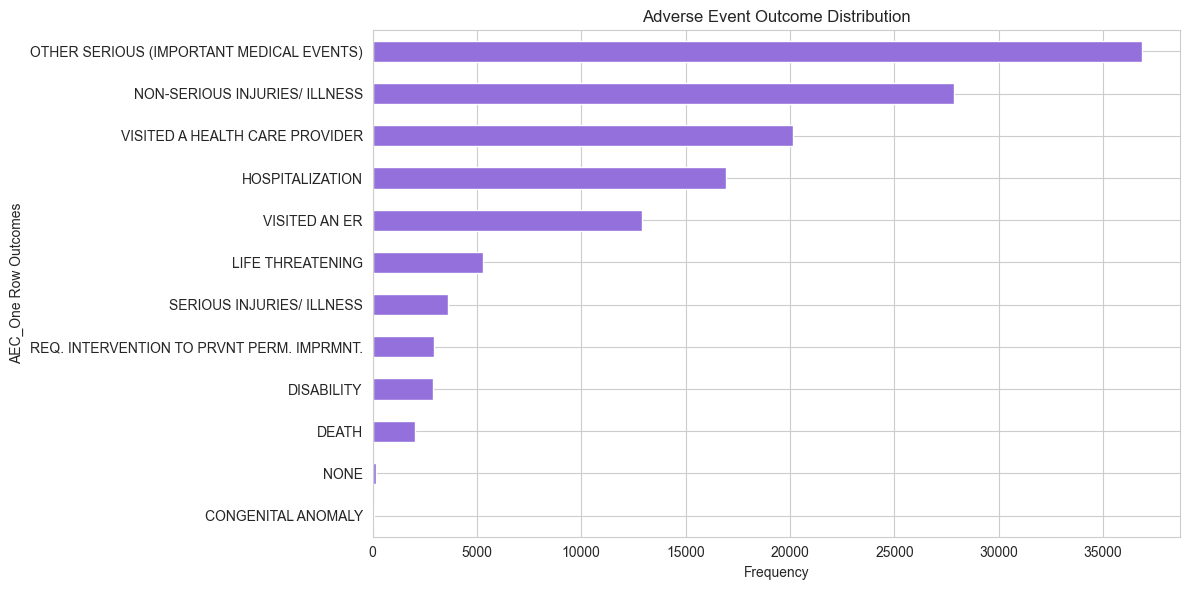

In [9]:
# Split comma-separated outcomes and count individual occurrences
all_outcomes = df["AEC_One Row Outcomes"].dropna().str.split(", ").explode().str.strip()
outcome_counts = all_outcomes.value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
outcome_counts.plot(kind="barh", ax=ax, color="mediumpurple")
ax.set_title("Adverse Event Outcome Distribution")
ax.set_xlabel("Frequency")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Age Distribution of Reported Events

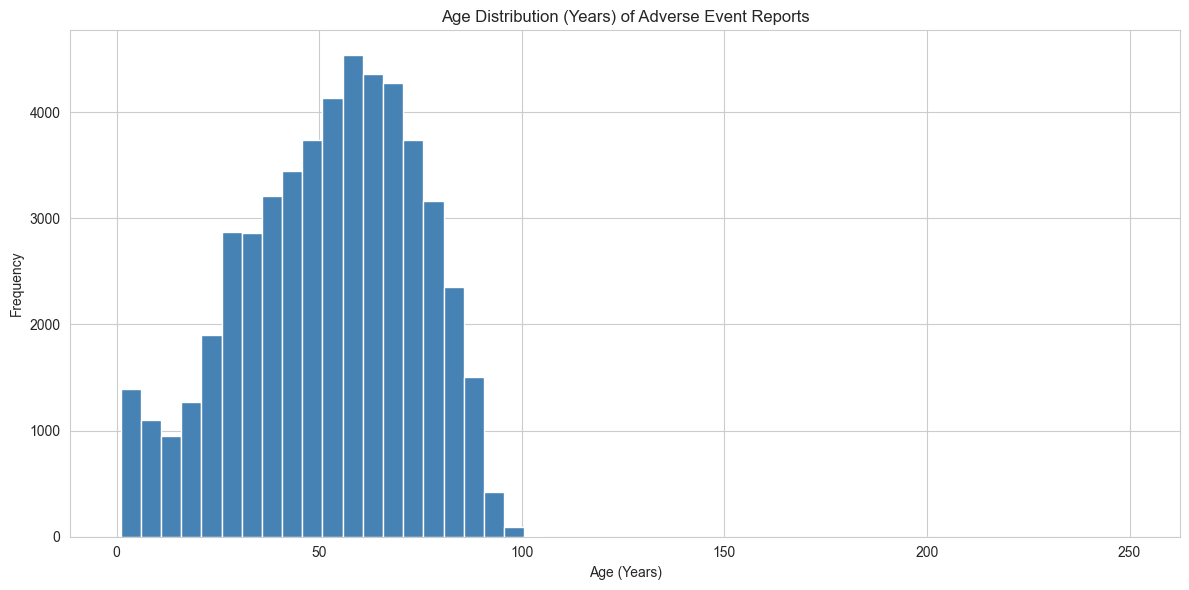

In [10]:
# Filter to rows with age in years for a meaningful histogram
age_years = df[df["CI_Age Unit"] == "Year(s)"]["CI_Age at Adverse Event"].dropna()

fig, ax = plt.subplots()
ax.hist(age_years, bins=50, color="steelblue", edgecolor="white")
ax.set_title("Age Distribution (Years) of Adverse Event Reports")
ax.set_xlabel("Age (Years)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()